In [2]:
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import numpy as np

In [3]:
os.listdir('data')

['wednesday.csv', 'tuesday.csv', 'monday.csv', 'friday.csv', 'thursday.csv']

In [4]:
!head data/monday.csv

timestamp;customer_no;location
2019-09-02 07:03:00;1;dairy
2019-09-02 07:03:00;2;dairy
2019-09-02 07:04:00;3;dairy
2019-09-02 07:04:00;4;dairy
2019-09-02 07:04:00;5;spices
2019-09-02 07:04:00;6;spices
2019-09-02 07:04:00;7;spices
2019-09-02 07:04:00;8;fruit
2019-09-02 07:05:00;1;checkout


In [5]:
path = 'data'
data = pd.DataFrame()
for file in os.listdir(path):
    df = pd.read_csv(os.path.join(path,file), sep=';')
    df['timestamp'] = pd.to_datetime(df['timestamp'], format="%Y-%m-%d %H:%M:%S")
    data = pd.concat([data,df])
data = data.sort_values(by=['timestamp']).reset_index(drop=True)

In [13]:
data[data['day']==0]

,timestamp,customer_no,location,day
0,2019-09-02 07:03:00,1,dairy,0
1,2019-09-02 07:03:00,2,dairy,0
2,2019-09-02 07:04:00,3,dairy,0
3,2019-09-02 07:04:00,4,dairy,0
4,2019-09-02 07:04:00,5,spices,0
...,...,...,...,...
4879,2019-09-02 21:49:00,1442,checkout,0
4880,2019-09-02 21:49:00,1444,checkout,0
4881,2019-09-02 21:49:00,1445,dairy,0
4882,2019-09-02 21:50:00,1446,dairy,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24877 entries, 0 to 24876
Data columns (total 3 columns):
timestamp      24877 non-null datetime64[ns]
customer_no    24877 non-null int64
location       24877 non-null object
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 583.2+ KB


In [7]:
data['day'] = data['timestamp'].dt.dayofweek

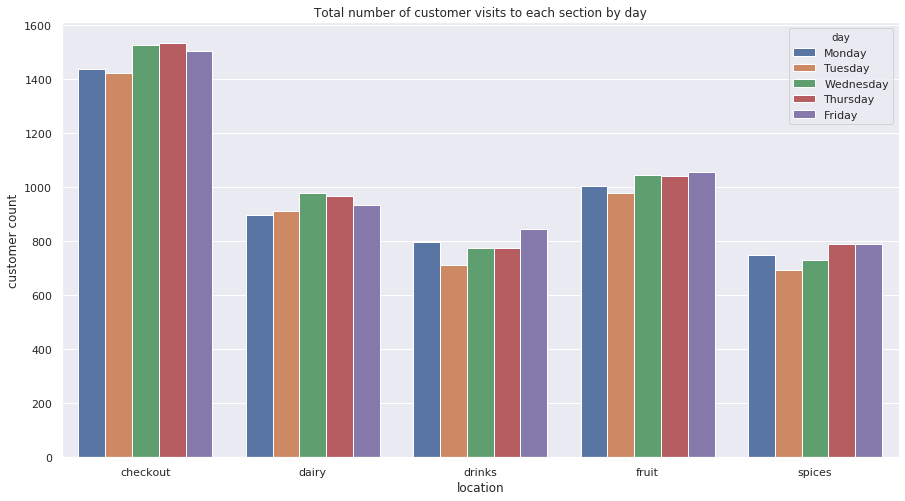

In [8]:
plot_data = data.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
# plot_data['time_window'] = data['timestamp'].dt.floor('5T').dt.time
plot_data = plot_data.groupby(['location', plot_data['day']]).count()
plot_data = plot_data[['customer_no']].reset_index()
plot_data = plot_data.rename(columns={'customer_no':'customer count'})
plot_data

fig, ax = plt.subplots(figsize=(15,8))
sns.barplot(x='location', y='customer count', hue='day', #style='day',
             data=plot_data, ax=ax, ci=None,
             hue_order=['Monday','Tuesday','Wednesday','Thursday','Friday'],
           );
title = "Total number of customer visits to each section by day"
ax.set_title(title);
# ax.set_xlim=(plot_data['time_window'].min().floor('D'), plot_data['time_window'].max().ceil('D'));


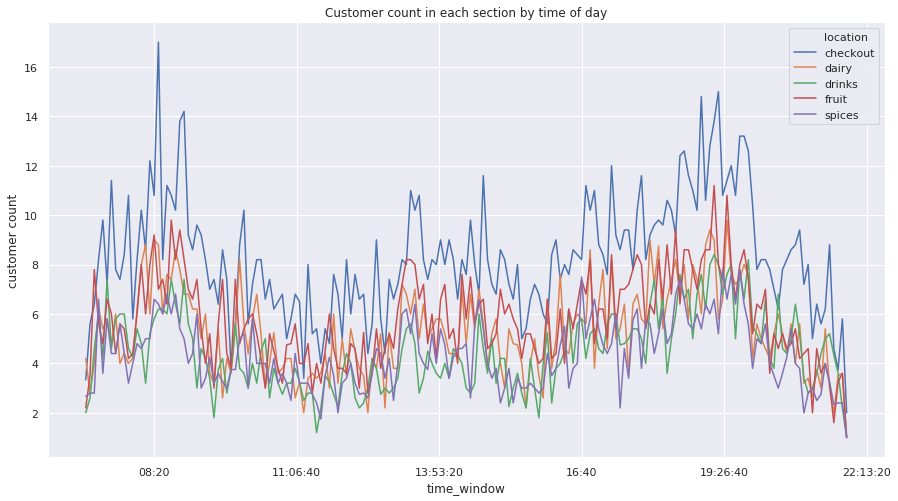

In [9]:
plot_data = data.copy()
plot_data['day'] = data['timestamp'].dt.dayofweek
plot_data['time_window'] = data['timestamp'].dt.floor('5T').dt.time
plot_data = plot_data.groupby(['location', plot_data['time_window'], plot_data['day']]).count()
plot_data = plot_data[['customer_no']].reset_index()
plot_data = plot_data.rename(columns={'customer_no':'customer count'})

fig, ax = plt.subplots(figsize=(15,8))
sns.lineplot(x='time_window', y='customer count', hue='location',
             data=plot_data, ax=ax, ci=None);
title = "Customer count in each section by time of day"
ax.set_title(title);
# ax.set_xlim=(plot_data['time_window'].min().floor('D'), plot_data['time_window'].max().ceil('D'));


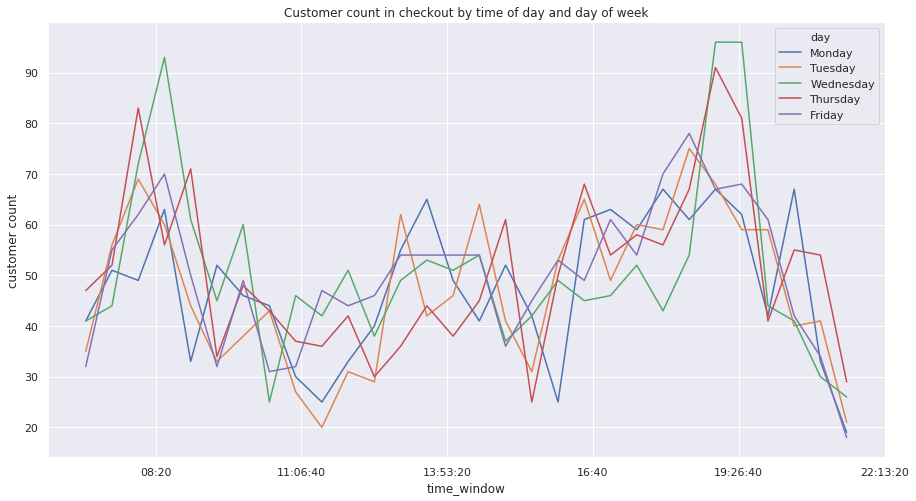

In [10]:
plot_data = data.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
plot_data['time_window'] = data['timestamp'].dt.floor('30T').dt.time
plot_data = plot_data.groupby(['location', plot_data['time_window'], plot_data['day']]).count()
plot_data = plot_data[['customer_no']].reset_index()
plot_data = plot_data.rename(columns={'customer_no':'customer count'})
plot_data = plot_data[plot_data['location']=='checkout']

fig, ax = plt.subplots(figsize=(15,8))
sns.lineplot(x='time_window', y='customer count', hue='day', #style='day',
             data=plot_data, ax=ax, ci=None, 
             hue_order=['Monday','Tuesday','Wednesday','Thursday','Friday'],
            );
title = "Customer count in checkout by time of day and day of week"
ax.set_title(title);
# ax.set_xlim=(plot_data['time_window'].min().floor('D'), plot_data['time_window'].max().ceil('D'));


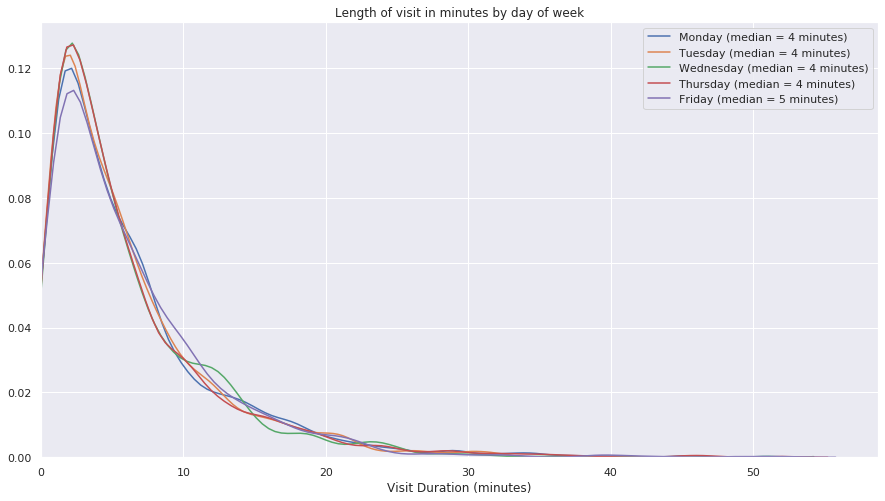

In [11]:
plot_data = data.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
plot_data['time_window'] = data['timestamp'].dt.floor('60T').dt.time
entry = plot_data.groupby(['customer_no','day'])['timestamp'].min()
exit = plot_data.groupby(['customer_no','day'])['timestamp'].max()
time_spent = exit - entry
duration = time_spent.rename('Visit Duration (minutes)').dt.seconds/60
plot_data = duration.reset_index() #.rename(columns={'timestamp':'duration'})

fig, ax = plt.subplots(figsize=(15,8))
for day in ['Monday','Tuesday','Wednesday','Thursday','Friday']:
    df = plot_data[plot_data['day']==day]
    label = "{} (median = {:.0f} minutes)".format(day, df['Visit Duration (minutes)'].median())
    sns.distplot(a=df['Visit Duration (minutes)'], ax=ax, label=label, 
                 hist=False,
#                 clip=(0,60),
#                  kde=False,
                );
ax.legend();
title = "Length of visit in minutes by day of week"
ax.set_title(title);
ax.set_xlim(0,None);

# median_table = plot_data.groupby('day')['Visit Duration (minutes)'].median().rename('Median duration')
# median_table = median_table.loc[['Monday','Tuesday','Wednesday','Thursday','Friday']]
# table = ax.table(cellText = median_table.values.reshape(-1,1),
#                  rowLabels=median_table.index, colWidths=[0.1],
#                  loc="right", #bbox=
#                  );



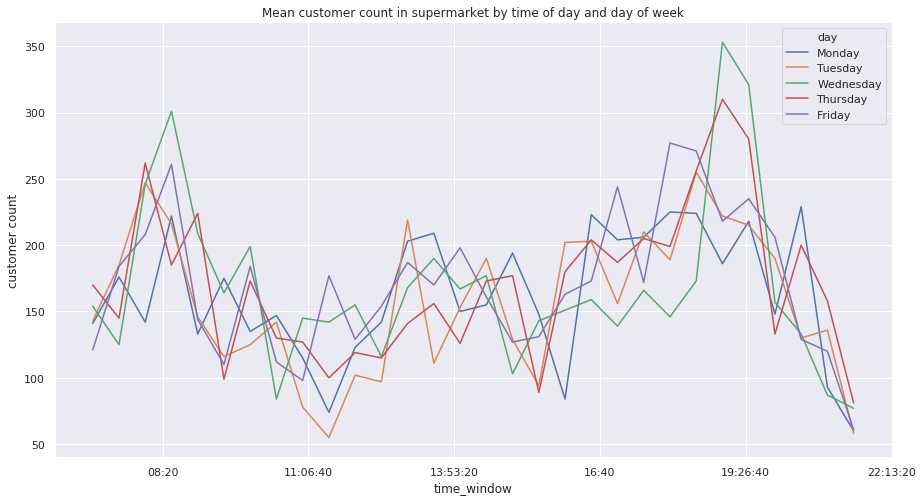

In [11]:
plot_data = data.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
plot_data['time_window'] = data['timestamp'].dt.floor('30T').dt.time
plot_data = plot_data.groupby([plot_data['time_window'], plot_data['day']])
plot_data = plot_data.count()[['customer_no']]
plot_data = plot_data.rename(columns={'customer_no':'customer count'})


plot_data = plot_data.reset_index()


fig, ax = plt.subplots(figsize=(15,8))
sns.lineplot(x='time_window', y='customer count', hue='day', #style='day',
             data=plot_data, ax=ax, ci=None, 
             hue_order=['Monday','Tuesday','Wednesday','Thursday','Friday'],
            );
title = "Mean customer count in supermarket by time of day and day of week"
ax.set_title(title);
# ax.set_xlim=(plot_data['time_window'].min().floor('D'), plot_data['time_window'].max().ceil('D'));

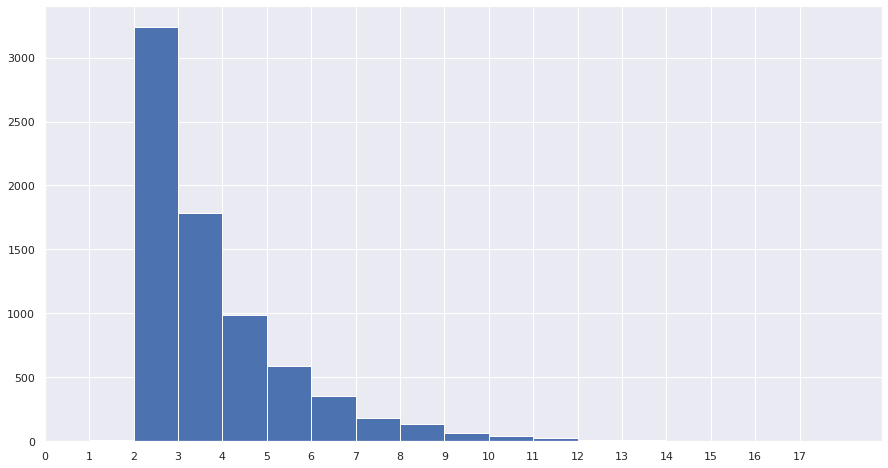

In [12]:
# show distribution of number of 'aisle visits' by each customer
plot_data = data.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
fig, ax = plt.subplots(figsize=(15,8))
num_sections = plot_data.groupby(['day', 'customer_no'])['location'].count()# - 1
num_sections.hist(bins=17, ax=ax);
ax.xaxis.set_ticks(range(18));

In [13]:
# find duration spend in each aisle

plot_data = data.sort_values(by=['timestamp'])#.copy()
idx = plot_data.groupby(['day', 'customer_no']).all().index
df_times = pd.DataFrame(index=idx)
df_durations = pd.DataFrame(index=idx)
df_locations = pd.DataFrame(index=idx)

max_sections = plot_data.groupby(['day', 'customer_no'])['location'].count().max()
for n in range(max_sections):
    df_times[n] = plot_data.groupby(['day','customer_no']).nth(n)['timestamp']
    
    df_locations[n] = plot_data.groupby(['day','customer_no']).nth(n)['location']
    
    if n>0:
        df_durations[n-1] = (df_times[n] - df_times[n-1]).dt.seconds
    
df_durations

0   1   2   3   4   5   6   7   8   9   10  11  12  13  \
day customer_no                                                              
0   1            120.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    2            180.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    3            120.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    4            240.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    5             60.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...                ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
4   1506           NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    1507         120.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    1508         120.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    1509           NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
    1510           NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

                 14  15  16  
day customer_no              
0   1           NaN NaN NaN  
    2           NaN NaN NaN  
    3           NaN NaN NaN  
    4           NaN NaN NaN  
    5           NaN NaN NaN  
...              ..  ..  ..  
4   1506        NaN NaN NaN  
    1507        NaN NaN NaN  
    1508        NaN NaN NaN  
    1509        NaN NaN NaN  
    1510        NaN NaN NaN  

[7445 rows x 17 columns]

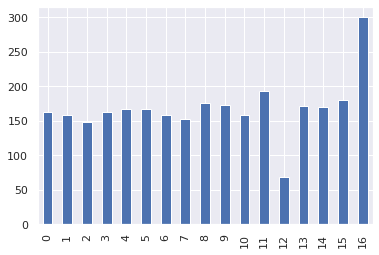

In [14]:
# show average length of time spent in section by visit number
pd.Series(np.nanmean(df_durations,axis=0)).plot.bar();

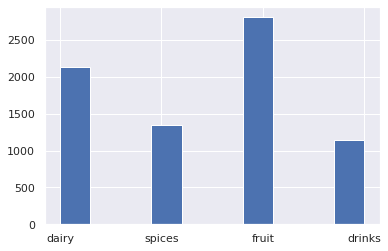

In [15]:
# histogram of the first aisle to be visited
df_locations[0].hist();

In [16]:
day_trans = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}

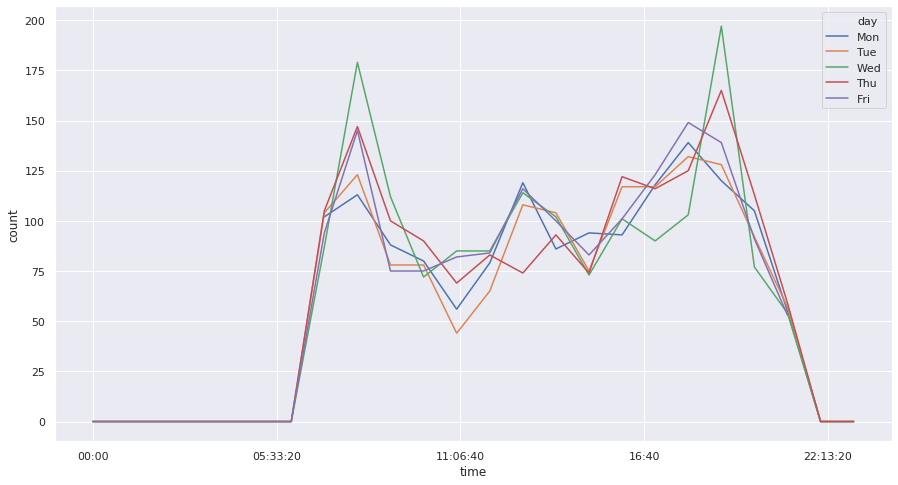

In [17]:
# distribution of customers entering at each time of day
freq = '60T'
plot_data = df_times[0].rename('time').reset_index().set_index('time').resample(freq).count().reset_index()
plot_data['day'] = plot_data['time'].dt.dayofweek.map(day_trans)
plot_data['time'] = plot_data['time'].dt.time
plot_data = plot_data.rename(columns={'customer_no':'count'})

fig, ax = plt.subplots(figsize=(15,8));
sns.lineplot(x='time', y='count', hue='day', data=plot_data, ax=ax);

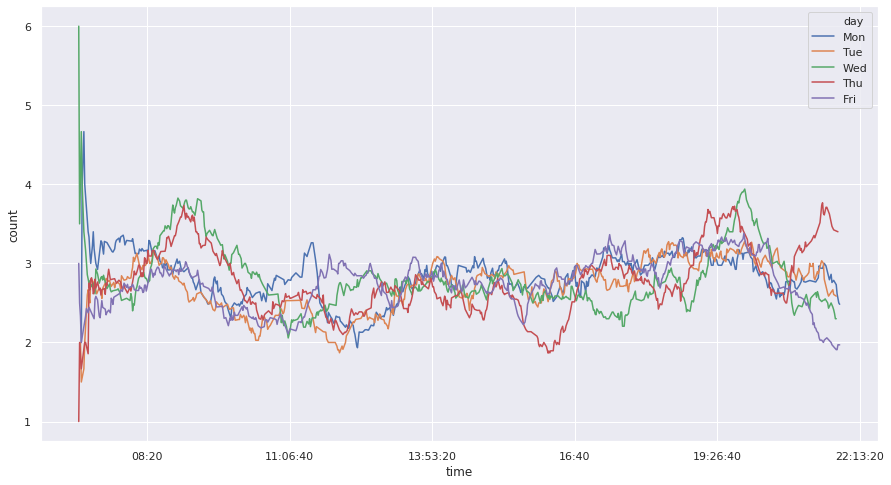

In [33]:
# distribution of customers entering at each time of day
freq = '60T'
plot_data = df_times[0].rename('time').reset_index().groupby('time').count().rolling(freq).mean().reset_index()
plot_data['day'] = plot_data['time'].dt.dayofweek.map(day_trans)
plot_data['time'] = plot_data['time'].dt.time
plot_data = plot_data.rename(columns={'customer_no':'count'})

fig, ax = plt.subplots(figsize=(15,8));
sns.lineplot(x='time', y='count', hue='day', data=plot_data, ax=ax);

In [35]:
plot_data['count'].describe()

count    2667.000000
mean        2.798816
std         0.368844
min         1.000000
25%         2.575758
50%         2.793103
75%         3.022233
max         6.000000
Name: count, dtype: float64

28 customers did not visit the checkout


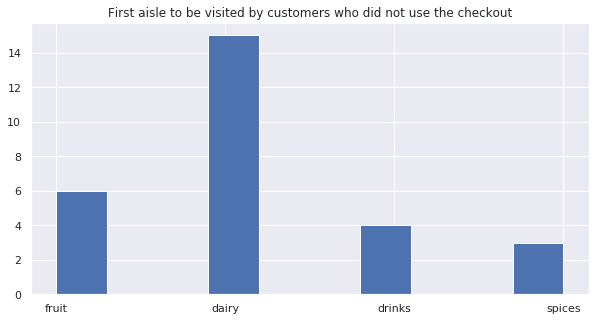

In [20]:
# customers that did not visit the checkout
print(f"{df_locations[~np.any(df_locations=='checkout',axis=1)].shape[0]} customers did not visit the checkout")

fig, ax = plt.subplots(figsize=(10,5))
df_locations[~np.any(df_locations=='checkout',axis=1)][0].hist(ax=ax);
title = 'First aisle to be visited by customers who did not use the checkout'
ax.set_title(title);

In [21]:
# enter the estimated revenue per minute for each aisle
revenue_per_min = pd.Series([4, 3, 5, 6, 0],
                            index=['fruit', 'spices', 'dairy', 'drinks', 'checkout'],
                            name='revenue per minute'
                           )
revenue_per_min

fruit       4
spices      3
dairy       5
drinks      6
checkout    0
Name: revenue per minute, dtype: int64

In [22]:
# estimate revenue per customer
# remove customers that didn't visit the checkout
df_revenue = df_locations[np.any(df_locations=='checkout',axis=1)].fillna('checkout') 
df_revenue = df_revenue.applymap(lambda x: revenue_per_min[x]) * df_durations / 60
# df_revenue.sum(axis=1)

In [23]:
# estimate potential lost revenue
df_lost_revenue = df_locations[~np.any(df_locations=='checkout',axis=1)].fillna('checkout') 
df_lost_revenue = df_lost_revenue.applymap(lambda x: revenue_per_min[x]) * df_durations / 60
df_lost_revenue.sum().sum()

611.0

The most profitable aisle is drinks, with total revenue €23430


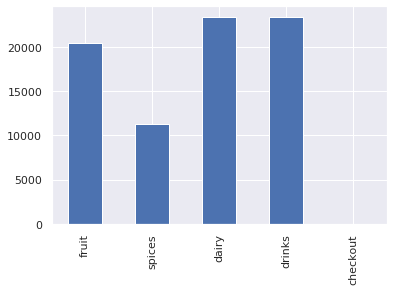

In [24]:
revenue_per_section = pd.Series()
for section in revenue_per_min.index:
    revenue_per_section.loc[section] = (np.where(df_locations==section, 1, 0) * revenue_per_min[section]).sum()

most_prof = revenue_per_section[revenue_per_section==revenue_per_section.max()].index[0]
print(f"The most profitable aisle is {most_prof}, with total revenue €{revenue_per_section.max()}")
revenue_per_section.plot.bar();

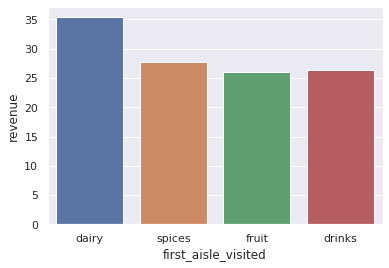

In [25]:
# plot revenue per customer vs first aisle visited
rev_vs_first_aisle = pd.DataFrame(df_revenue.sum(axis=1).rename('revenue'))\
                        .join(df_locations[0].rename('first_aisle_visited'))
sns.barplot(x='first_aisle_visited', y='revenue', data=rev_vs_first_aisle, ci=None);

### Transition probabilities

In [26]:
aisles = revenue_per_section.index.tolist()
aisles

['fruit', 'spices', 'dairy', 'drinks', 'checkout']

In [27]:
# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
transition_matrix = pd.DataFrame(columns=aisles, index=aisles[:-1])
transition_matrix.index.rename('start aisle', inplace=True)
transition_matrix.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_locations.copy()
dummy_locations[999] = np.nan

# loop through the aisles, find the table indeces where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for a in aisles[:-1]:
    instances_a = np.where(dummy_locations==a)
    instances_next = (instances_a[0], instances_a[1] + 1)
    transition_matrix.loc[a] = pd.Series(dummy_locations.values[instances_next]).value_counts()


# the total number of transitions from each aisle is the sum along the rows
total_transitions = transition_matrix.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba = transition_matrix.div(total_transitions,axis=0)
transition_proba

/home/flann/.local/lib/python3.7/site-packages/pandas/core/ops/__init__.py:1115: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)


next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,NaN,0.125904,0.238319,0.136266,0.499511
spices,0.152307,NaN,0.323553,0.27314,0.251
dairy,0.189925,0.195713,NaN,0.223151,0.391211
drinks,0.219062,0.216756,0.0271586,NaN,0.537023


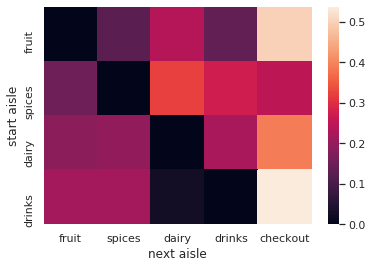

In [28]:
sns.heatmap(transition_proba.fillna(0));

In [29]:
import networkx as nx

In [30]:
graph = nx.Graph()

graph.add_nodes_from(aisles)

graph.nodes

edges = [(s,f) for s in transition_matrix.index for f in transition_matrix.columns 
         if not np.isnan(transition_matrix.loc[s,f])]

graph.add_edges_from(edges)

graph.edges

EdgeView([('fruit', 'spices'), ('fruit', 'dairy'), ('fruit', 'drinks'), ('fruit', 'checkout'), ('spices', 'dairy'), ('spices', 'drinks'), ('spices', 'checkout'), ('dairy', 'drinks'), ('dairy', 'checkout'), ('drinks', 'checkout')])

In [31]:
transition_proba

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,NaN,0.125904,0.238319,0.136266,0.499511
spices,0.152307,NaN,0.323553,0.27314,0.251
dairy,0.189925,0.195713,NaN,0.223151,0.391211
drinks,0.219062,0.216756,0.0271586,NaN,0.537023


In [32]:
weighted_edges = [(s,f, transition_proba.loc[s,f]) 
                  for s in transition_matrix.index 
                  for f in transition_matrix.columns 
                  if not np.isnan(transition_matrix.loc[s,f])]

In [38]:
weighted_edges

[('fruit', 'spices', 0.12590420332355817),
 ('fruit', 'dairy', 0.2383186705767351),
 ('fruit', 'drinks', 0.13626588465298142),
 ('fruit', 'checkout', 0.4995112414467253),
 ('spices', 'fruit', 0.15230728194185117),
 ('spices', 'dairy', 0.32355294745265406),
 ('spices', 'drinks', 0.27313950386769803),
 ('spices', 'checkout', 0.25100026673779674),
 ('dairy', 'fruit', 0.18992497320471596),
 ('dairy', 'spices', 0.1957127545551983),
 ('dairy', 'drinks', 0.22315112540192927),
 ('dairy', 'checkout', 0.3912111468381565),
 ('drinks', 'fruit', 0.21906225980015373),
 ('drinks', 'spices', 0.2167563412759416),
 ('drinks', 'dairy', 0.027158595951831923),
 ('drinks', 'checkout', 0.5370228029720727)]

In [39]:
DG = nx.DiGraph()
DG.add_nodes_from(aisles)
DG.add_weighted_edges_from(weighted_edges)

In [58]:
from matplotlib import cm
cmap = cm.get_cmap('plasma')

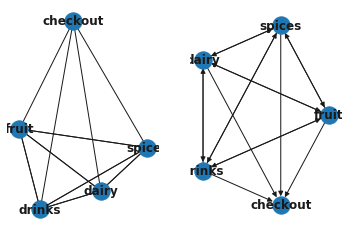

In [59]:
plt.subplot(121)
nx.draw(DG, with_labels=True, font_weight='bold', edge_cmap=cmap, style='-', arrows=False)

plt.subplot(122)
nx.draw_shell(DG, with_labels=True, font_weight='bold', cmap=cmap)

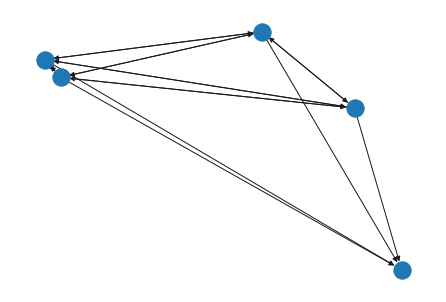

In [49]:
nx.draw_kamada_kawai(DG, edge_cmap=cmap)

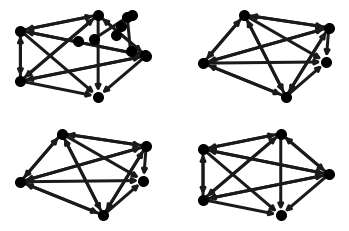

In [42]:
options = {
    'node_color': 'black',
    'node_size': 100,
    'width': 3,
}
plt.subplot(221)
nx.draw_random(G, **options)
nx.draw_circular(DG, **options)
plt.subplot(222)
nx.draw_spectral(DG, **options)
plt.subplot(223)
nx.draw_spectral(DG, **options)
plt.subplot(224)
nx.draw_shell(DG, **options)

In [114]:
# get probabilities for first aisle visited
first_aisle_proba = pd.DataFrame(index=aisles)

first_aisle_proba['all days'] = df_locations[0].value_counts() / df_locations[0].count()

for day in df_locations.index.levels[0]:
    first_aisle_proba[f'day {day}'] = df_locations.loc[day,0].value_counts() / df_locations.loc[day,0].count()

In [115]:
first_aisle_proba

,all days,day 0,day 1,day 2,day 3,day 4
fruit,0.377435,0.359364,0.393108,0.378184,0.368730,0.388079
spices,0.181464,0.195577,0.159634,0.163945,0.194137,0.193377
dairy,0.287576,0.284727,0.292546,0.301764,0.295114,0.263576
drinks,0.153526,0.160332,0.154712,0.156107,0.142020,0.154967
checkout,NaN,NaN,NaN,NaN,NaN,NaN


In [142]:
# calculate the transition matrix by day

# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
day_idx = ['all'] + list(range(5))
multi_idx = pd.MultiIndex.from_product([day_idx,aisles[:-1]], names=['day','start aisle'])
transition_matrix_by_day = pd.DataFrame(columns=aisles, index=multi_idx)
# transition_matrix_by_day.index.rename('start aisle', inplace=True)
transition_matrix_by_day.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_locations.copy()
dummy_locations[999] = np.nan

# loop through the aisles, find the table indices where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for day in day_idx:
    for a in aisles[:-1]:
        if day == 'all':
            key = day_idx[1:]
        else:
            key = day
        instances_a = np.where(dummy_locations.loc[key]==a)
        instances_next = (instances_a[0], instances_a[1] + 1)
        counts = pd.Series(dummy_locations.loc[key].values[instances_next]).value_counts()
        transition_matrix_by_day.loc[(day,a)] = counts


# the total number of transitions from each aisle is the sum along the rows
total_transitions_by_day = transition_matrix_by_day.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_by_day = transition_matrix_by_day.div(total_transitions_by_day,axis=0)
transition_proba_by_day

next aisle          fruit    spices      dairy    drinks  checkout
day start aisle                                                   
all fruit             NaN  0.125904   0.238319  0.136266  0.499511
    spices       0.152307       NaN   0.323553   0.27314     0.251
    dairy        0.189925  0.195713        NaN  0.223151  0.391211
    drinks       0.219062  0.216756  0.0271586       NaN  0.537023
0   fruit             NaN  0.121878   0.224775   0.12987  0.523477
    spices       0.159091       NaN   0.314171  0.290107  0.236631
    dairy         0.20202  0.205387        NaN  0.244669  0.347924
    drinks       0.233375  0.203262  0.0288582       NaN  0.534504
1   fruit             NaN  0.131148   0.237705  0.132172  0.498975
    spices       0.144092       NaN   0.354467  0.262248  0.239193
    dairy        0.184818  0.206821        NaN   0.20022  0.408141
    drinks       0.208976  0.211781  0.0238429       NaN    0.5554
2   fruit             NaN  0.117195   0.243996  0.126801  0.512008
    spices       0.146776       NaN   0.323731   0.26749  0.262003
    dairy        0.177618  0.201232        NaN  0.214579  0.406571
    drinks       0.237419  0.207742  0.0309677       NaN  0.523871
3   fruit             NaN  0.134486   0.225744  0.132565  0.507205
    spices       0.150633       NaN   0.322785  0.265823  0.260759
    dairy        0.201663  0.183992        NaN  0.218295   0.39605
    drinks       0.208763  0.225515  0.0283505       NaN  0.537371
4   fruit             NaN     0.125   0.258523  0.159091  0.457386
    spices       0.159898       NaN   0.305838  0.279188  0.255076
    dairy        0.184069  0.181916        NaN  0.238967  0.395048
    drinks       0.206651  0.233967   0.023753       NaN  0.535629

## Recalculate the transition matrix using a timestep of 1 minute

In [905]:
df_location_by_time = data.sort_values(by=['customer_no', 'timestamp'])
entrance_time = df_location_by_time.groupby(['day', 'customer_no']).nth(0)['timestamp']
df_location_by_time = df_location_by_time.set_index(['day', 'customer_no'])
time_elapsed = df_location_by_time['timestamp'] - entrance_time
df_location_by_time['time_elapsed'] = time_elapsed.sort_index(level=1).values ### THIS IS A BIT HAIRY - add unique index ###
df_location_by_time = df_location_by_time.reset_index().set_index(['day', 'customer_no','time_elapsed'])['location']
df_location_by_time = df_location_by_time.unstack(-1).reindex(pd.timedelta_range('00S', '3600S', freq='60S'), axis=1) 
df_location_by_time = df_location_by_time.fillna(method='ffill', axis=1)
df_location_by_time

00:00:00  00:01:00  00:02:00  00:03:00  00:04:00  00:05:00  \
day customer_no                                                              
0   1              dairy     dairy  checkout  checkout  checkout  checkout   
    2              dairy     dairy     dairy  checkout  checkout  checkout   
    3              dairy     dairy  checkout  checkout  checkout  checkout   
    4              dairy     dairy     dairy     dairy  checkout  checkout   
    5             spices  checkout  checkout  checkout  checkout  checkout   
...                  ...       ...       ...       ...       ...       ...   
4   1506           dairy     dairy     dairy     dairy     dairy     dairy   
    1507           dairy     dairy  checkout  checkout  checkout  checkout   
    1508           dairy     dairy  checkout  checkout  checkout  checkout   
    1509          drinks    drinks    drinks    drinks    drinks    drinks   
    1510          spices    spices    spices    spices    spices    spices   

                 00:06:00  00:07:00  00:08:00  00:09:00  ...  00:51:00  \
day customer_no                                          ...             
0   1            checkout  checkout  checkout  checkout  ...  checkout   
    2            checkout  checkout  checkout  checkout  ...  checkout   
    3            checkout  checkout  checkout  checkout  ...  checkout   
    4            checkout  checkout  checkout  checkout  ...  checkout   
    5            checkout  checkout  checkout  checkout  ...  checkout   
...                   ...       ...       ...       ...  ...       ...   
4   1506            dairy     dairy     dairy     dairy  ...     dairy   
    1507         checkout  checkout  checkout  checkout  ...  checkout   
    1508         checkout  checkout  checkout  checkout  ...  checkout   
    1509           drinks    drinks    drinks    drinks  ...    drinks   
    1510           spices    spices    spices    spices  ...    spices   

                 00:52:00  00:53:00  00:54:00  00:55:00  00:56:00  00:57:00  \
day customer_no                                                               
0   1            checkout  checkout  checkout  checkout  checkout  checkout   
    2            checkout  checkout  checkout  checkout  checkout  checkout   
    3            checkout  checkout  checkout  checkout  checkout  checkout   
    4            checkout  checkout  checkout  checkout  checkout  checkout   
    5            checkout  checkout  checkout  checkout  checkout  checkout   
...                   ...       ...       ...       ...       ...       ...   
4   1506            dairy     dairy     dairy     dairy     dairy     dairy   
    1507         checkout  checkout  checkout  checkout  checkout  checkout   
    1508         checkout  checkout  checkout  checkout  checkout  checkout   
    1509           drinks    drinks    drinks    drinks    drinks    drinks   
    1510           spices    spices    spices    spices    spices    spices   

                 00:58:00  00:59:00  01:00:00  
day customer_no                                
0   1            checkout  checkout  checkout  
    2            checkout  checkout  checkout  
    3            checkout  checkout  checkout  
    4            checkout  checkout  checkout  
    5            checkout  checkout  checkout  
...                   ...       ...       ...  
4   1506            dairy     dairy     dairy  
    1507         checkout  checkout  checkout  
    1508         checkout  checkout  checkout  
    1509           drinks    drinks    drinks  
    1510           spices    spices    spices  

[7445 rows x 61 columns]

In [910]:
# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
transition_matrix_minutely = pd.DataFrame(columns=aisles, index=aisles[:-1])
transition_matrix_minutely.index.rename('start aisle', inplace=True)
transition_matrix_minutely.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_location_by_time.copy()
dummy_locations["23:59:59"] = np.nan

# loop through the aisles, find the table indeces where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for a in aisles[:-1]:
    instances_a = np.where(dummy_locations==a)
    instances_next = (instances_a[0], instances_a[1] + 1)
    transition_matrix_minutely.loc[a] = pd.Series(dummy_locations.values[instances_next]).value_counts()


# the total number of transitions from each aisle is the sum along the rows
total_transitions = transition_matrix_minutely.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_minutely = transition_matrix_minutely.div(total_transitions,axis=0)
transition_proba_minutely

/home/flann/.local/lib/python3.7/site-packages/pandas/core/ops/__init__.py:1115: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)


next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.608945,0.049235,0.093196,0.053287,0.195336
spices,0.087202,0.427459,0.185247,0.156384,0.143708
dairy,0.047794,0.049250,0.748355,0.056155,0.098446
drinks,0.086873,0.085958,0.010770,0.603434,0.212965


In [911]:
# calculate the transition matrix by day

# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
day_idx = ['all'] + list(range(5))
multi_idx = pd.MultiIndex.from_product([day_idx,aisles[:-1]], names=['day','start aisle'])
transition_matrix_by_day_minutely = pd.DataFrame(columns=aisles, index=multi_idx)
# transition_matrix_by_day_minutely.index.rename('start aisle', inplace=True)
transition_matrix_by_day_minutely.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_location_by_time.copy()
dummy_locations["23:59:59"] = np.nan

# loop through the aisles, find the table indices where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for day in day_idx:
    for a in aisles[:-1]:
        if day == 'all':
            key = day_idx[1:]
        else:
            key = day
        instances_a = np.where(dummy_locations.loc[key]==a)
        instances_next = (instances_a[0], instances_a[1] + 1)
        counts = pd.Series(dummy_locations.loc[key].values[instances_next]).value_counts()
        transition_matrix_by_day_minutely.loc[(day,a)] = counts


# the total number of transitions from each aisle is the sum along the rows
total_transitions_by_day = transition_matrix_by_day_minutely.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_by_day_minutely = transition_matrix_by_day_minutely.div(total_transitions_by_day,axis=0)
transition_proba_by_day_minutely

next aisle          fruit    spices     dairy    drinks  checkout
day start aisle                                                  
all fruit        0.608945  0.049235  0.093196  0.053287  0.195336
    spices       0.087202  0.427459  0.185247  0.156384  0.143708
    dairy        0.047794  0.049250  0.748355  0.056155  0.098446
    drinks       0.086873  0.085958  0.010770  0.603434  0.212965
0   fruit        0.639149  0.043980  0.081110  0.046864  0.188897
    spices       0.088740  0.442207  0.175242  0.161820  0.131991
    dairy        0.048309  0.049114  0.760870  0.058508  0.083199
    drinks       0.090865  0.079140  0.011236  0.610650  0.208109
1   fruit        0.585034  0.054422  0.098639  0.054847  0.207058
    spices       0.086133  0.402239  0.211886  0.156761  0.142980
    dairy        0.047218  0.052839  0.744519  0.051152  0.104272
    drinks       0.086227  0.087384  0.009838  0.587384  0.229167
2   fruit        0.597759  0.047141  0.098145  0.051005  0.205951
    spices       0.082881  0.435321  0.182804  0.151046  0.147947
    dairy        0.046183  0.052322  0.739989  0.055793  0.105713
    drinks       0.094214  0.082437  0.012289  0.603175  0.207885
3   fruit        0.608057  0.052711  0.088479  0.051958  0.198795
    spices       0.088279  0.413947  0.189169  0.155786  0.152819
    dairy        0.050129  0.045736  0.751421  0.054264  0.098450
    drinks       0.086400  0.093333  0.011733  0.586133  0.222400
4   fruit        0.610332  0.048708  0.100738  0.061993  0.178229
    spices       0.089552  0.439943  0.171286  0.156361  0.142857
    dairy        0.047004  0.046454  0.744640  0.061023  0.100880
    drinks       0.077713  0.087986  0.008933  0.623939  0.201429

In [438]:
transition_proba_minutely

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.608945,0.049235,0.093196,0.053287,0.195336
spices,0.087202,0.427459,0.185247,0.156384,0.143708
dairy,0.047794,0.049250,0.748355,0.056155,0.098446
drinks,0.086873,0.085958,0.010770,0.603434,0.212965
